In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting
import scipy as sp
from joblib import Parallel, delayed
import itertools
from qutip.qip.operations import rz, cz_gate, cnot, rx, hadamard_transform, swap

In [1]:
EL = 0.377  # Inductive energy
EJ = 6.013  # Josephson energy # 5.412, 6.013
EC_phi = 1.142  # Phi mode charging energy
EC_theta = 0.092  # Theta mode charging energy

# Compute derived parameters
E_CJ = 2 * EC_phi
E_C = 2 / (1 / EC_theta - 1 / EC_phi)
print(f"E_CJ = {E_CJ}, E_C = {E_C}")

E_CJ = 2.284, E_C = 0.20012190476190478


## Prepare two zero pi 

In [2]:
args_all = ut.get_operator_two_zeropi()

In [3]:
[n_theta1, n_theta2, n_theta1_dress, n_theta2_dress, n_theta1_truc, n_theta2_truc,
eval_tot, order_sort, H0, trunc_states, eket0, eket1, eket_tot  ] = args_all

truc = len(trunc_states)
state_tot = [qt.basis(truc, i) for i in range(truc)]

e_ops = [qt.basis(truc, i) * qt.basis(truc, i).dag()
        for i in range(truc)]

# Trans ;  w_ij;    n_theta1; n_theta2; sum
# 00-14 ;  45.925 ;  0.032 ;  0.006 ;  0.038
# 20-14 ;  24.289 ;  0.046 ;  0.001 ;  0.047
logi_space = ['00', '02', '20', '22']
[ w_00_14, w_20_14, n_theta1_00_14, n_theta2_00_14,
n_theta1_20_14, n_theta2_20_14] = ut.get_transition_freq(args_all)

H_qbt_drive = [ H0, [2*np.pi*n_theta1_truc, ut.drive_gauss_A],
                    [2*np.pi*n_theta1_truc, ut.drive_gauss_B]  ]

n1n1 = True
args = (w_00_14, w_20_14, n_theta1_00_14, n_theta2_00_14,
        n_theta1_20_14, n_theta2_20_14, state_tot, H_qbt_drive, n1n1)


## Chevron 1A - Population around optimal points


### $A_1 + \delta_1$

In [4]:
def get_pop(args, state_0='00'):
    drive_amp_A, drive_amp_B, tg, detune_A, detune_B = args

    pulse_args = {'drive_amp_A': drive_amp_A* (n_theta1_20_14/n_theta1_00_14) ,
                'drive_freq_A': w_00_14 + 2*np.pi*detune_A,
                'drive_amp_B': drive_amp_B ,
                'drive_freq_B': w_20_14 + 2*np.pi*detune_B,
                'gate_time': tg }

    tlist = np.linspace(0, tg, num=1000)  # total time
    options = qt.Options(nsteps=10000, store_states=True)
    result = qt.mesolve(
        H=H_qbt_drive,
        rho0=qt.basis( len(trunc_states), logi_space.index(state_0) ),
        tlist=tlist,
        e_ops=e_ops,
        args=pulse_args,
        options=options
    )
    return result.expect[0][-1]

In [9]:
argz = (n_theta1_20_14, n_theta1_00_14, w_00_14, w_20_14,
 trunc_states, logi_space, H_qbt_drive, e_ops )

A1, A2, t_g, d1, d2 = [1.98e-02,  4.64e-02,  4.529436e+02, -3.22e-02, -2.66e-02]
A_list = np.linspace(-0.02, 0.05, 31)
detune_list = np.linspace(-0.008, 0.025, 31)
A_vec = A1 + A_list
detune_vec = d1 + detune_list

values_grid = list(itertools.product(A_vec, [A2], [t_g], detune_vec, [d2]))
pop = Parallel(n_jobs=-1, verbose=1)(delayed(ut.get_pop)(arg, *argz)
                                            for arg in values_grid)
pop = np.reshape(pop, (len(A_vec), len(detune_vec)))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 256 concurrent workers.
[Parallel(n_jobs=-1)]: Done 288 tasks      | elapsed:   16.8s
[Parallel(n_jobs=-1)]: Done 961 out of 961 | elapsed:   27.5s finished


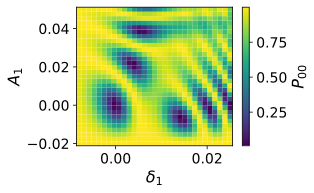

In [10]:
fig, ax = plt.subplots(figsize=(3.5,2.5))
plt.pcolormesh( detune_list, A_list, pop)
plt.xlabel('$\delta_1$')
plt.ylabel('$A_1$')
plt.colorbar(label='$P_{00}$')
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

### $A_1 + t_g$

In [8]:

A1, A2, t_g, d1, d2 = [1.98e-02,  4.64e-02,  4.529436e+02, -3.22e-02, -2.66e-02]
A_list = np.linspace(-0.02, 0.05, 31)
tg_list = np.linspace(-452, 300, 31)
detune_list = np.linspace(-0.008, 0.025, 51)
A_vec = A1 + A_list
tg_vec = t_g + tg_list
detune_vec = d1 + detune_list

values_grid = list(itertools.product(A_vec, [A2], tg_vec, [d1], [d2]))
pop = Parallel(n_jobs=-1, verbose=1)(delayed(ut.get_pop)(arg)
                                            for arg in values_grid)
pop = np.reshape(pop, (len(A_vec), len(tg_vec)))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 256 concurrent workers.


ValueError: not enough values to unpack (expected 8, got 0)

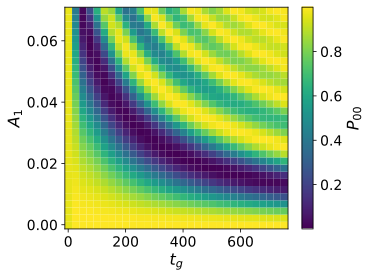

In [ ]:
fig, ax = plt.subplots(figsize=(3.5,2.5))
plt.pcolormesh( tg_vec, A_vec, pop)
plt.xlabel('$t_g$')
plt.ylabel('$A_1$')
plt.colorbar(label='$P_{00}$')
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

### $A_1 + A_2$

In [ ]:

A1, A2, t_g, d1, d2 = [1.98e-02,  4.64e-02,  4.529436e+02, -3.22e-02, -2.66e-02]
A_list = np.linspace(-0.0198, 0.05, 71)
A2_list = np.linspace(-0.0198, 0.02, 41)
tg_list = np.linspace(-452, 300, 31)
detune_list = np.linspace(-0.008, 0.025, 81)
A1_vec = A1 + A_list
A2_vec = A2 + A2_list
tg_vec = t_g + tg_list
detune_vec = d1 + detune_list

values_grid = list(itertools.product(A1_vec, A2_vec, [t_g], [d1], [d2]))
pop = Parallel(n_jobs=-1, verbose=1)(delayed(ut.get_pop)(arg)
                                            for arg in values_grid)
pop = np.reshape(pop, (len(A_list), len(A2_list)))

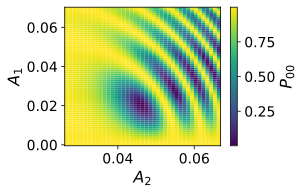

In [ ]:
fig, ax = plt.subplots(figsize=(3.5,2.5))
plt.pcolormesh( A2_vec, A1_vec, pop)
plt.xlabel('$A_2$')
plt.ylabel('$A_1$')
plt.colorbar(label='$P_{00}$')
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

### $t_g + \delta_1$

In [ ]:
A1, A2, t_g, d1, d2 = [1.98e-02,  4.64e-02,  4.529436e+02, -3.22e-02, -2.66e-02]
tg_list = np.linspace(-452, 600, 61)
detune_list = np.linspace(-0.008, 0.0322, 61)
tg_vec = t_g + tg_list
detune_vec = d1 + detune_list

values_grid = list(itertools.product([A1], [A2], tg_vec, detune_vec, [d2]))
pop = Parallel(n_jobs=-1, verbose=1)(delayed(ut.get_pop)(arg)
                                            for arg in values_grid)
pop = np.reshape(pop, (len(tg_vec), len(detune_vec)))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 256 concurrent workers.
[Parallel(n_jobs=-1)]: Done 288 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 738 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done 1288 tasks      | elapsed:   13.2s
[Parallel(n_jobs=-1)]: Done 1938 tasks      | elapsed:   25.5s
[Parallel(n_jobs=-1)]: Done 2688 tasks      | elapsed:   44.7s
[Parallel(n_jobs=-1)]: Done 3721 out of 3721 | elapsed:  1.3min finished


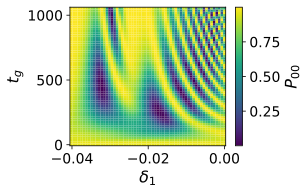

In [ ]:
fig, ax = plt.subplots(figsize=(3.5,2.5))
plt.pcolormesh( detune_vec, tg_vec, pop)
plt.ylabel('$t_g$')
plt.xlabel('$\delta_1$')
plt.colorbar(label='$P_{00}$')
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')